<a href="https://colab.research.google.com/github/Breeto-2001/Breeti-Chakraborty/blob/main/marketing%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
data= pd.read_excel("/data.xlsx")
country = pd.read_excel("/Country-Code.xlsx")

In [5]:
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9550 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

In [7]:
data.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [8]:
print(data.isnull().sum())

Restaurant ID           0
Restaurant Name         1
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [9]:
print(data.isnull().sum().sum())

10


In [10]:
print(data.duplicated().sum())

0


In [ ]:
# 3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants
# 4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence
# 5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking
# 6. Find out the percentage of restaurants providing online delivery
# 7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

In [11]:
data= pd.merge(data, country, on="Country Code", how="left")
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,Indonesia
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,Indonesia
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,Indonesia
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,Indonesia
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,Indonesia


In [12]:
city_counts=data['City'].value_counts()
city_counts

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
...,...
Vernonia,1
Dicky Beach,1
Inverloch,1


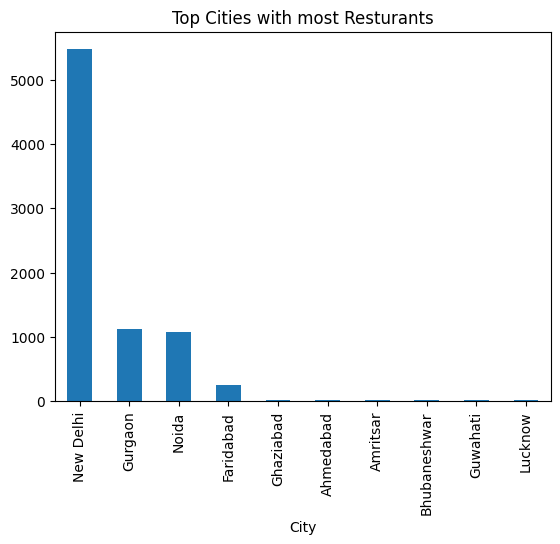

('New Delhi', 'Bandung')

In [15]:
city_counts.head(10).plot(kind='bar')
plt.title("Top Cities with most Resturants")
plt.show()

#max and min

city_counts.idxmax(),city_counts.idxmin()

In [17]:
chain=data['Restaurant Name'].value_counts()

#Resturants with multiple outlets
franchise = chain[chain > 1]

franchise.head(10)

,count
Restaurant Name,
Cafe Coffee Day,83
Domino's Pizza,79
Subway,63
Green Chick Chop,51
McDonald's,48
Keventers,34
Pizza Hut,30
Giani,29
Baskin Robbins,28


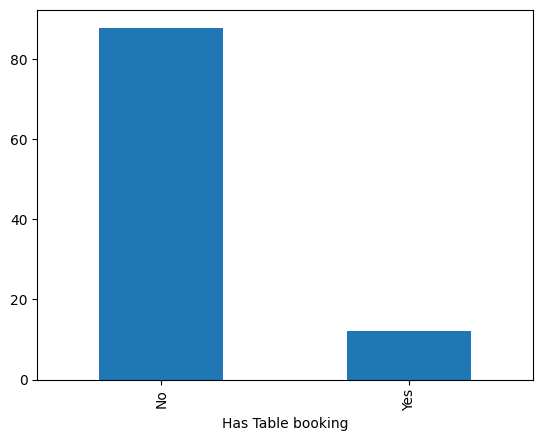

In [18]:
table_booking=data["Has Table booking"].value_counts(normalize=True)*100
table_booking.plot(kind='bar')
plt.show()

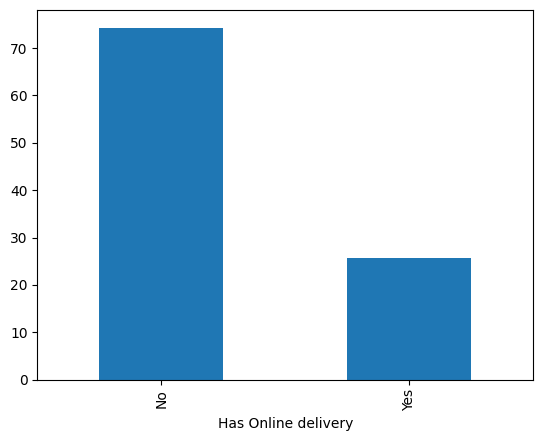

In [19]:
table_delivery=data["Has Online delivery"].value_counts(normalize=True)*100
table_delivery.plot(kind='bar')
plt.show()

In [ ]:
table_booking=data["Has Table booking"].value_counts(normalize=True)*100
table_booking.plot(kind='bar')
plt.show()

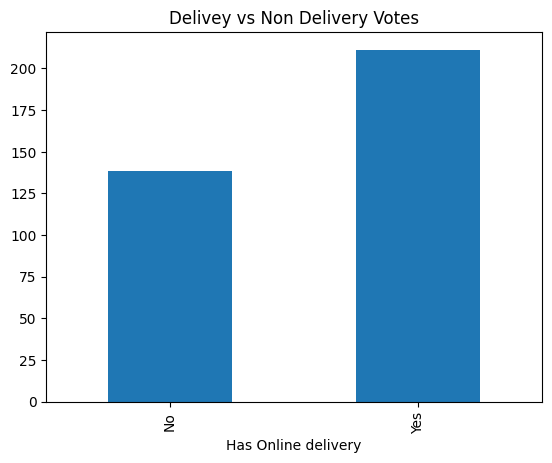

In [20]:
votes_delivery=data.groupby("Has Online delivery")['Votes'].mean()
votes_delivery.plot(kind='bar')
plt.title("Delivey vs Non Delivery Votes")
plt.show()

In [11]:
# Count restaurants by table booking option
table_booking_counts = data['Has Table booking'].value_counts()

# Calculate ratio
ratio = table_booking_counts['Yes'] / table_booking_counts['No']
print("Ratio (Table booking allowed : Not allowed) =", ratio)

Ratio (Table booking allowed : Not allowed) = 0.13797211962349576


In [12]:
# Percentage of restaurants with online delivery
online_delivery_percentage = data['Has Online delivery'].value_counts(normalize=True) * 100
print("Percentage of restaurants providing online delivery:")
print(online_delivery_percentage)

Percentage of restaurants providing online delivery:
Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


In [13]:
# Average votes grouped by delivery option
votes_delivery = data.groupby('Has Online delivery')['Votes'].mean()

# Difference
difference = votes_delivery['Yes'] - votes_delivery['No']
print("Difference in average votes (Delivery vs Non-Delivery) =", difference)

Difference in average votes (Delivery vs Non-Delivery) = 73.17609478166429


In [14]:
# Split cuisines by comma and count frequency
cuisine_counts = data['Cuisines'].str.split(',').explode().str.strip().value_counts()

print("Top 10 cuisines served across cities:")
print(cuisine_counts.head(10))

Top 10 cuisines served across cities:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


In [16]:
# Count cuisines per restaurant, handling NaN values
data['Cuisine_Count'] = data['Cuisines'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and x != '' else 0)

max_cuisines = data['Cuisine_Count'].max()
min_cuisines = data['Cuisine_Count'].min()

print("Maximum cuisines served by a restaurant:", max_cuisines)
print("Minimum cuisines served by a restaurant:", min_cuisines)

# Most served cuisine per city, handling cases with no valid cuisines
most_cuisine_city = data.groupby('City')['Cuisines'].apply(
    lambda x: x.dropna().str.split(',').explode().str.strip().value_counts().idxmax()
    if not x.dropna().empty else 'No Cuisines Specified'
)
print("Most served cuisine per city:")
print(most_cuisine_city)

Maximum cuisines served by a restaurant: 8
Minimum cuisines served by a restaurant: 0
Most served cuisine per city:
City
Abu Dhabi                Indian
Agra               North Indian
Ahmedabad           Continental
Albany                    Steak
Allahabad          North Indian
                       ...     
Weirton                  Burger
Wellington City            Cafe
Winchester Bay           Burger
Yorkton                   Asian
€¡stanbul              Desserts
Name: Cuisines, Length: 141, dtype: object


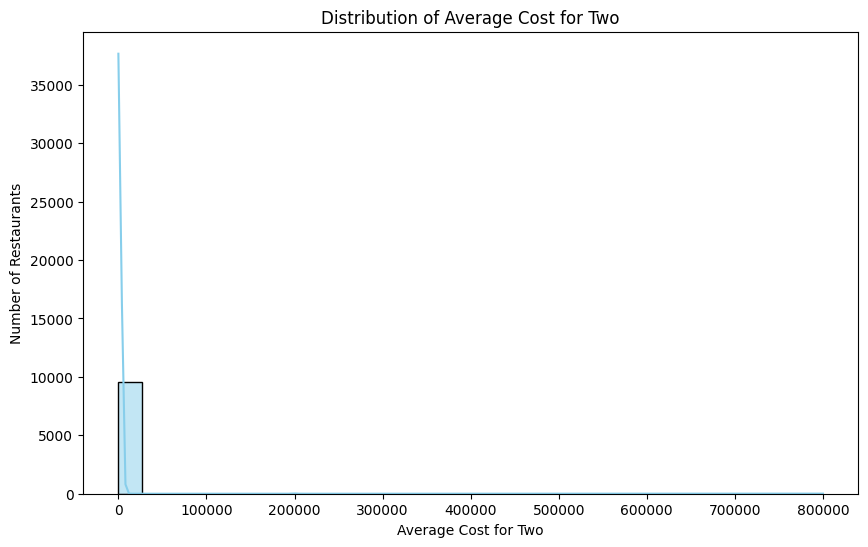

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data['Average Cost for two'], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Average Cost for Two")
plt.xlabel("Average Cost for Two")
plt.ylabel("Number of Restaurants")
plt.show()

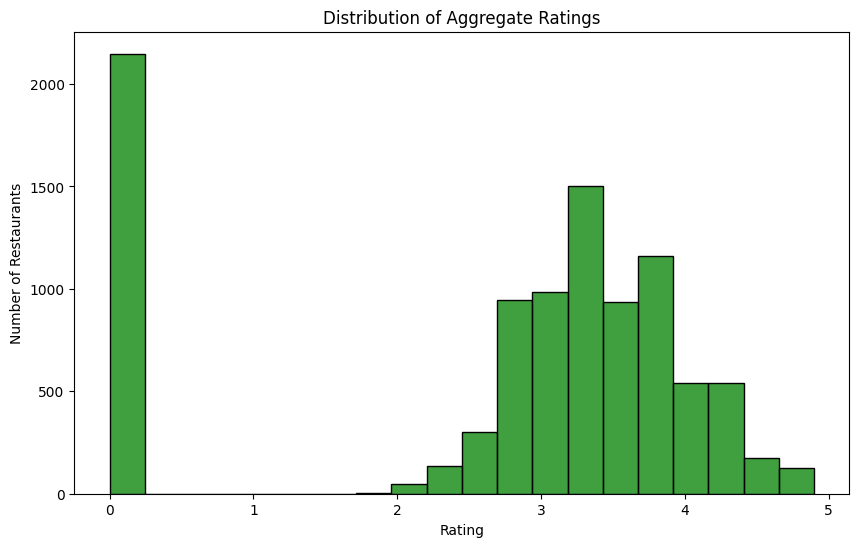

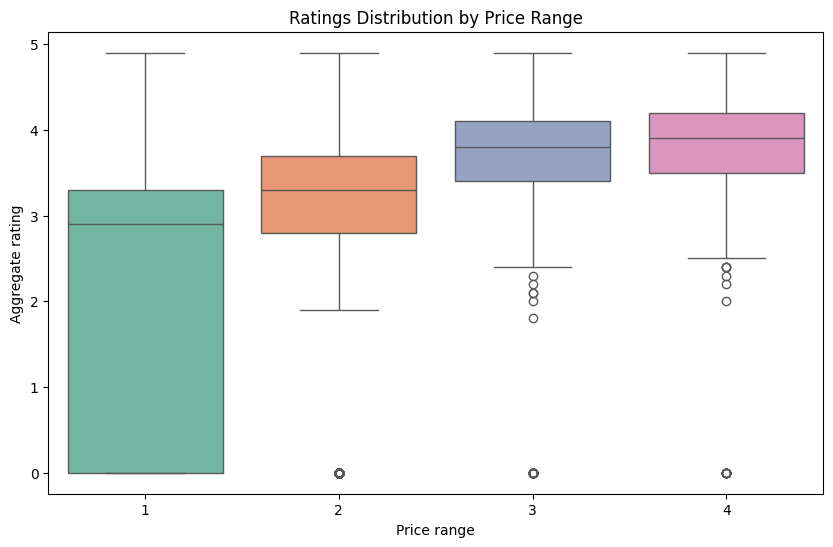

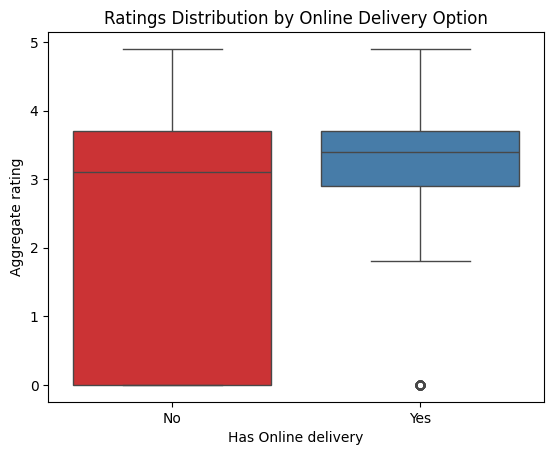

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(data['Aggregate rating'], bins=20, kde=False, color="green")
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

# Ratings vs Price Range
plt.figure(figsize=(10,6))
sns.boxplot(x='Price range', y='Aggregate rating', data=data, palette="Set2")
plt.title("Ratings Distribution by Price Range")
plt.show()

# Ratings vs Online Delivery
sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=data, palette="Set1")
plt.title("Ratings Distribution by Online Delivery Option")
plt.show()

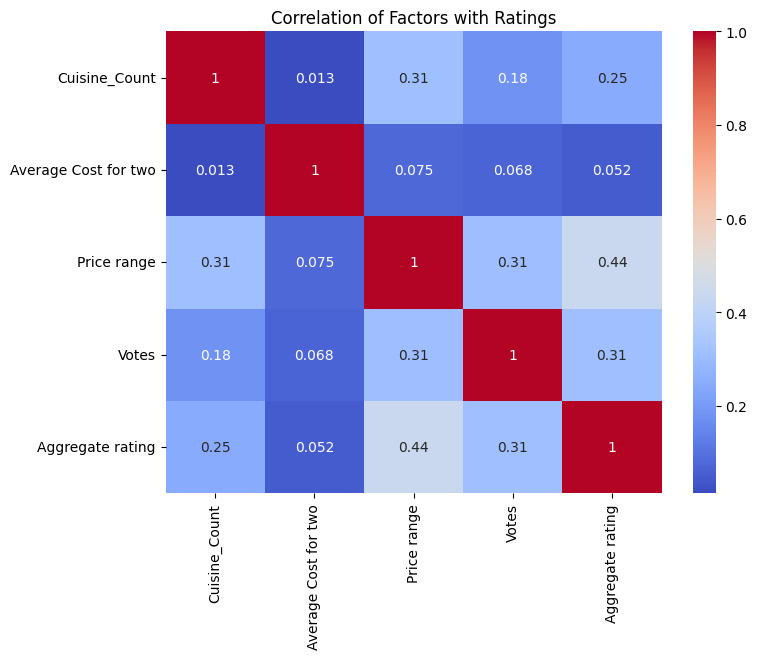

In [19]:
# Correlation matrix for numeric factors
numeric_cols = ['Cuisine_Count','Average Cost for two','Price range','Votes','Aggregate rating']
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation of Factors with Ratings")
plt.show()